<a href="https://colab.research.google.com/github/MNawfal24/MachineLearning/blob/main/MNawfalMA_JS05_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install & Import
!pip install hdbscan
import matplotlib.pyplot as plt
import hdbscan
from sklearn.datasets import make_blobs

# Buat Dataset X
centers = [[1, 1], [-1, -1], [1.5, -1.5]]
X, _ = make_blobs(n_samples=750, centers=centers, cluster_std=[0.4, 0.1, 0.75], random_state=0)

# Fungsi Plot Versi Singkat
def plot(X, labels, probabilities=None, parameters=None, ax=None):
    if ax is None: _, ax = plt.subplots(figsize=(8, 4))

    # Plot semua data sekaligus dengan warna bawaan
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='Spectral', s=20, edgecolor='k', alpha=0.7)

    # Hitung jumlah klaster (abaikan -1 karena itu noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    title = f"Estimated clusters: {n_clusters}"
    if parameters: title += f" | {parameters}"
    ax.set_title(title)

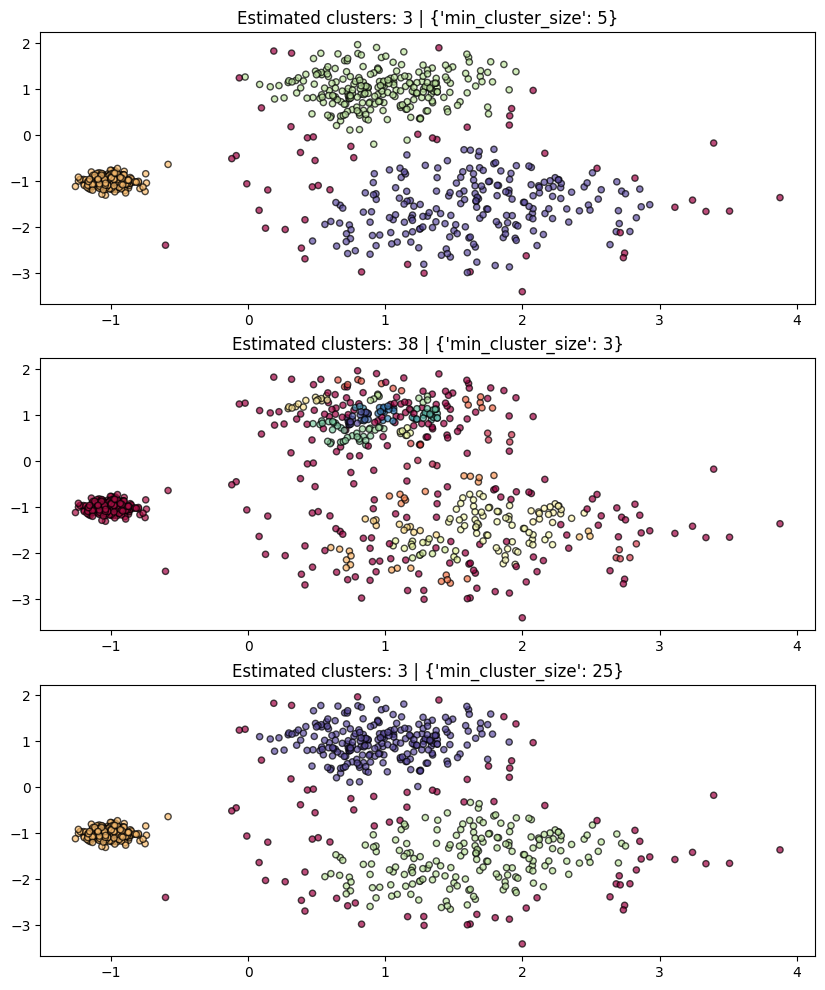

In [4]:
PARAM = (
    {"min_cluster_size": 5},
    {"min_cluster_size": 3},
    {"min_cluster_size": 25}
)

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    hdb = hdbscan.HDBSCAN(**param).fit(X)
    plot(X, hdb.labels_, hdb.probabilities_, param, ax=axes[i])
plt.show()

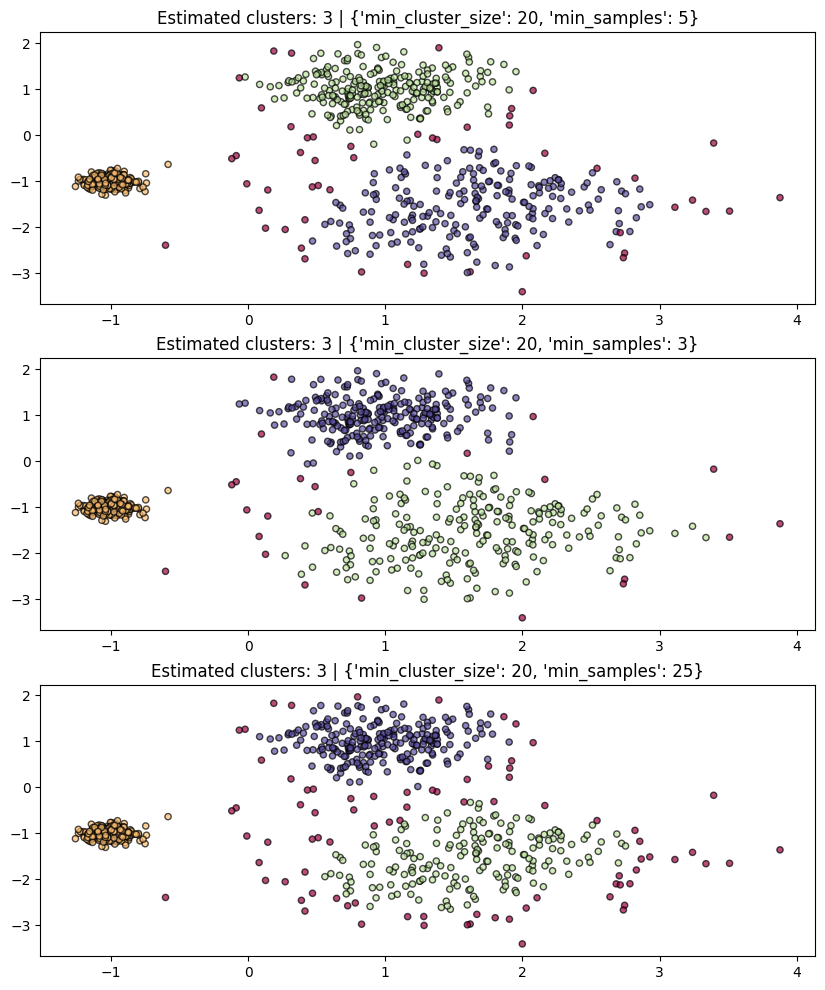

In [5]:
PARAM = (
    {"min_cluster_size": 20, "min_samples": 5},
    {"min_cluster_size": 20, "min_samples": 3},
    {"min_cluster_size": 20, "min_samples": 25},
)

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    hdb = hdbscan.HDBSCAN(**param).fit(X)
    plot(X, hdb.labels_, hdb.probabilities_, param, ax=axes[i])
plt.show()

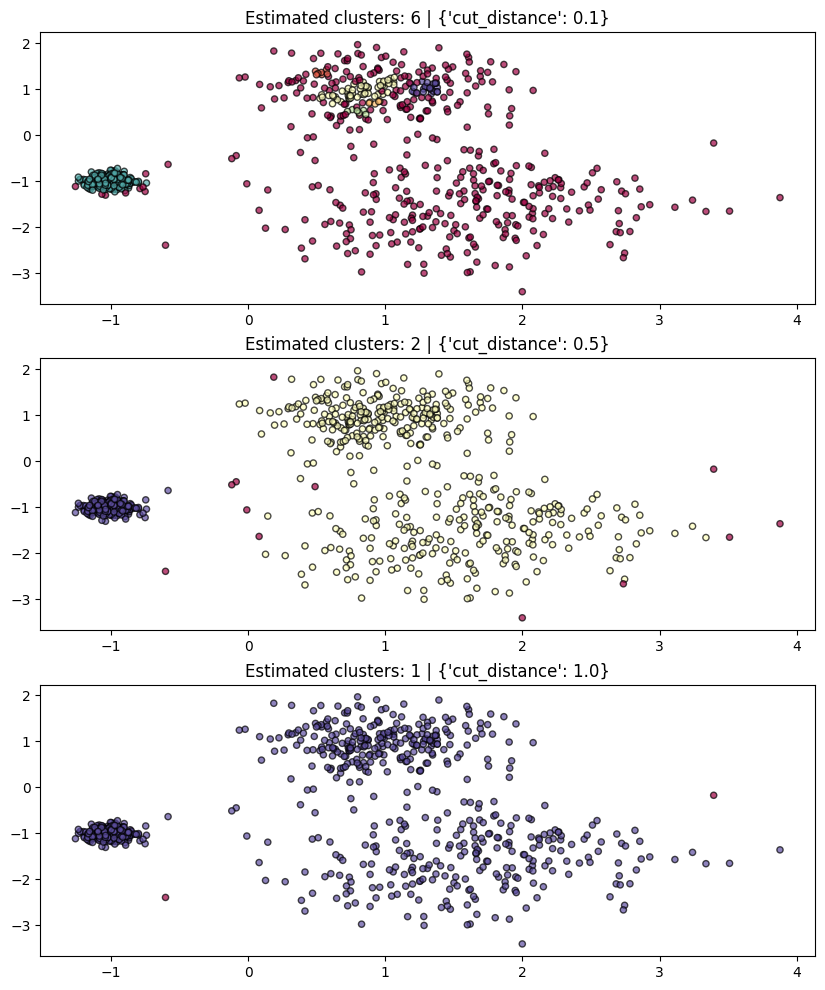

In [6]:
PARAM = (
    {"cut_distance": 0.1},
    {"cut_distance": 0.5},
    {"cut_distance": 1.0},
)

hdb = hdbscan.HDBSCAN().fit(X)
fig, axes = plt.subplots(len(PARAM), 1, figsize=(10, 12))

for i, param in enumerate(PARAM):
    labels = hdb.dbscan_clustering(**param)
    plot(X, labels, hdb.probabilities_, param, ax=axes[i])
plt.show()

In [7]:
from sklearn.metrics import silhouette_score

# Menghitung Silhouette Score untuk hasil clustering HDBSCAN
# (Menggunakan model 'hdb' dari sel sebelumnya yang menggunakan parameter default)
hdb_default = hdbscan.HDBSCAN().fit(X)
sil_score = silhouette_score(X, hdb_default.labels_)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.6451356578011034


In [8]:
from sklearn.metrics import davies_bouldin_score

# Menghitung Davies-Bouldin Index untuk hasil clustering HDBSCAN
dbi_score = davies_bouldin_score(X, hdb_default.labels_)
print(f"Davies-Bouldin Index: {dbi_score}")

Davies-Bouldin Index: 2.1284499880816123


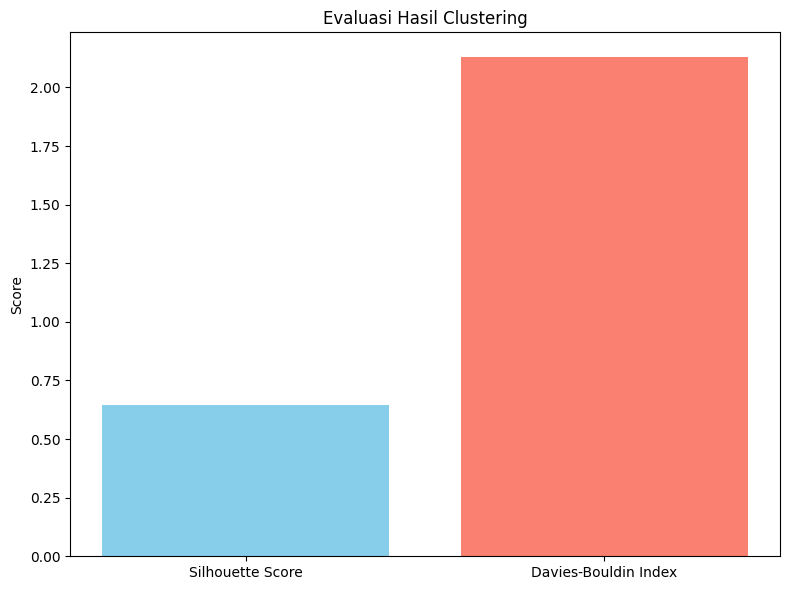

In [9]:
# Misalnya kita ingin membandingkan DBI dan Silhouette Score untuk beberapa eksperimen
scores = {
    "Silhouette Score": sil_score,
    "Davies-Bouldin Index": dbi_score
}

# Plot hasil evaluasi
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(scores.keys(), scores.values(), color=['skyblue', 'salmon'])
ax.set_title("Evaluasi Hasil Clustering")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()